# Math 9 Final Project

Atticus Wong, Ambareesh Lankipalli

### 1. Introduction and Guiding Questions

For our final project, we decided to analyze a dataset on student dropout and academic success. We chose this because we were curious on what factors would contribute the most to the success/failure of a student, which could then benefit more future decisions in our lives.

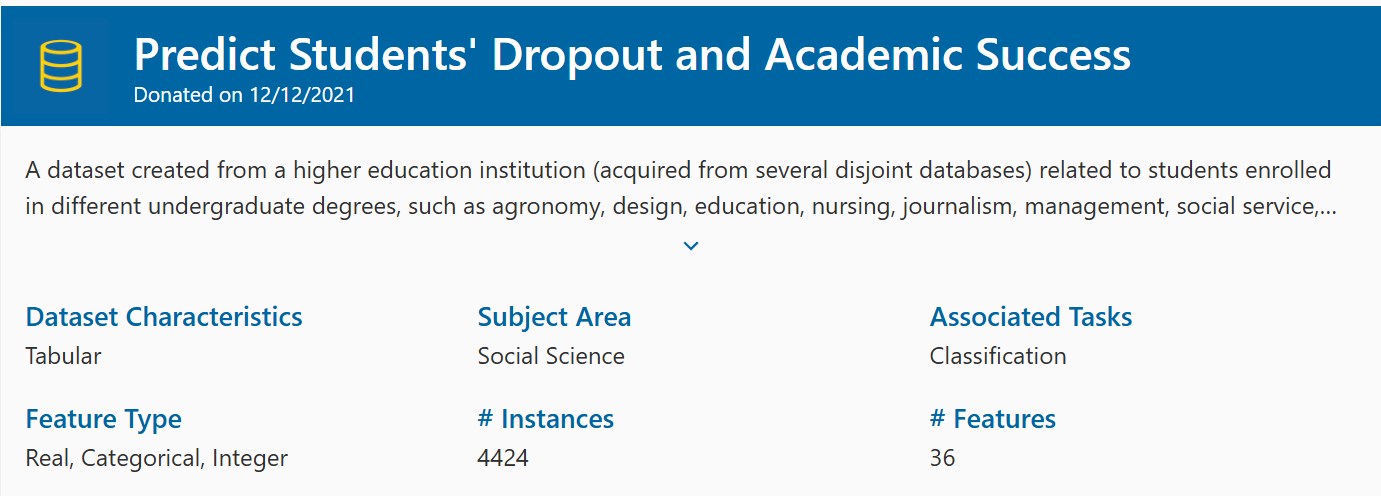

Our guiding questions are as follows:

1. What factors (that a student can/can't control) contribute the most to a student's academic outcomes?
- Since this may be too broad, I decided to follow up with some simpler questions
    - Are students with scholarships more likely to graduate than students without scholarships
    - How predictive are 1st-semester metrics of final outcome?
    - Do parents' previous qualifications affect dropout rate?

2. Can previous qualification factors predict performance?

3. What subgroup of students are the most likely to drop out?

4. TBD

Editor note: I didn't follow the question from the README.md. If you want, you can reorder them.

## Data Setup

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("data.csv", delimiter=";")
df.head(5)

,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,...,Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate


Important Columns:
- Curricular units 1st sem (grade): the grade of a student after 1st semester
- Curricular units 2nd sem (grade): the grade of a student after 2nd semester
- Target: Classification task at the end of the normal duration of a course

These columns will be important because with these, we can quantitavely and categorically measure a student's academic performance, and compare them against other columns in order to determine which factors have the greatest effect on a student's academic success.

Because this dataset displays its rows numerically rather than categorically, making it difficult to read, we convert back to categorical values with the categories given in the [website](https://archive.ics.uci.edu/dataset/697/predict+students+dropout+and+academic+success), along with using a comma as a delimiter instead of a semicolon. The code for doing so can be found in `scripts/convert_to_category.ipynb`.

In [8]:
df = pd.read_csv("student_data_categorized.csv")
df.head(5)


,Marital status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nationality,Mother's qualification,Father's qualification,...,2nd_sem_credited,2nd_sem_enrolled,2nd_sem_evaluations,2nd_sem_approved,2nd_sem_grade,2nd_sem_without_eval,Unemployment rate,Inflation rate,GDP,Target
0,Single,17,5,Animation and Multimedia Design,Daytime,Secondary education,122.0,Portuguese,Basic Education 3rd Cycle (9th/10th/11th Year)...,Other - 11th Year of Schooling,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,Single,15,1,Tourism,Daytime,Secondary education,160.0,Portuguese,Secondary Education - 12th Year of Schooling o...,Higher Education - Degree,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,Single,1,5,Communication Design,Daytime,Secondary education,122.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic education 1st cycle (4th/5th year) or eq...,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,Single,17,2,Journalism and Communication,Daytime,Secondary education,122.0,Portuguese,Basic Education 2nd Cycle (6th/7th/8th Year) o...,Basic education 1st cycle (4th/5th year) or eq...,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,Married,39,1,Social Service (evening attendance),Evening,Secondary education,100.0,Portuguese,Basic education 1st cycle (4th/5th year) or eq...,Basic Education 2nd Cycle (6th/7th/8th Year) o...,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
